In [1]:
print("hello")

hello


In [2]:
#import gymnasium as gym
import gym
import gym_jsbsim
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback         
import matplotlib.pyplot as plt
import os


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
import jsbsim
print(jsbsim.__version__)


1.1.1a


In [4]:
import jsbsim

print("JSBSim module type:", type(jsbsim))
print("Available attributes:", dir(jsbsim))
print("Module version:", getattr(jsbsim, '__version__', '⛔ 없음'))

try:
    print("Module file:", jsbsim.__file__)
except AttributeError:
    print("Module file: ⛔ 없음")


JSBSim module type: <class 'module'>
Available attributes: ['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__']
Module version: 1.1.1a
Module file: /mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/jsbsim/__init__.py


In [9]:
import gym
import gym_jsbsim

# JSBSim 관련 env 목록만 출력
envs = [env_id for env_id in gym.envs.registry.keys() if "JSBSim" in env_id]
print("\n".join(envs))


JSBSim-HeadingControlTask-Cessna172P-Shaping.STANDARD-FG-v0
JSBSim-HeadingControlTask-Cessna172P-Shaping.STANDARD-NoFG-v0
JSBSim-HeadingControlTask-Cessna172P-Shaping.EXTRA-FG-v0
JSBSim-HeadingControlTask-Cessna172P-Shaping.EXTRA-NoFG-v0
JSBSim-HeadingControlTask-Cessna172P-Shaping.EXTRA_SEQUENTIAL-FG-v0
JSBSim-HeadingControlTask-Cessna172P-Shaping.EXTRA_SEQUENTIAL-NoFG-v0
JSBSim-HeadingControlTask-A320-Shaping.STANDARD-FG-v0
JSBSim-HeadingControlTask-A320-Shaping.STANDARD-NoFG-v0
JSBSim-HeadingControlTask-A320-Shaping.EXTRA-FG-v0
JSBSim-HeadingControlTask-A320-Shaping.EXTRA-NoFG-v0
JSBSim-HeadingControlTask-A320-Shaping.EXTRA_SEQUENTIAL-FG-v0
JSBSim-HeadingControlTask-A320-Shaping.EXTRA_SEQUENTIAL-NoFG-v0
JSBSim-HeadingControlTask-F15-Shaping.STANDARD-FG-v0
JSBSim-HeadingControlTask-F15-Shaping.STANDARD-NoFG-v0
JSBSim-HeadingControlTask-F15-Shaping.EXTRA-FG-v0
JSBSim-HeadingControlTask-F15-Shaping.EXTRA-NoFG-v0
JSBSim-HeadingControlTask-F15-Shaping.EXTRA_SEQUENTIAL-FG-v0
JSBSim-Headin

In [6]:
from gym import envs
print("\n".join(envs.registry))

CartPole-v0
CartPole-v1
MountainCar-v0
MountainCarContinuous-v0
Pendulum-v1
Acrobot-v1
LunarLander-v2
LunarLanderContinuous-v2
BipedalWalker-v3
BipedalWalkerHardcore-v3
CarRacing-v2
Blackjack-v1
FrozenLake-v1
FrozenLake8x8-v1
CliffWalking-v0
Taxi-v3
Reacher-v2
Reacher-v4
Pusher-v2
Pusher-v4
InvertedPendulum-v2
InvertedPendulum-v4
InvertedDoublePendulum-v2
InvertedDoublePendulum-v4
HalfCheetah-v2
HalfCheetah-v3
HalfCheetah-v4
Hopper-v2
Hopper-v3
Hopper-v4
Swimmer-v2
Swimmer-v3
Swimmer-v4
Walker2d-v2
Walker2d-v3
Walker2d-v4
Ant-v2
Ant-v3
Ant-v4
Humanoid-v2
Humanoid-v3
Humanoid-v4
HumanoidStandup-v2
HumanoidStandup-v4
JSBSim-HeadingControlTask-Cessna172P-Shaping.STANDARD-FG-v0
JSBSim-HeadingControlTask-Cessna172P-Shaping.STANDARD-NoFG-v0
JSBSim-HeadingControlTask-Cessna172P-Shaping.EXTRA-FG-v0
JSBSim-HeadingControlTask-Cessna172P-Shaping.EXTRA-NoFG-v0
JSBSim-HeadingControlTask-Cessna172P-Shaping.EXTRA_SEQUENTIAL-FG-v0
JSBSim-HeadingControlTask-Cessna172P-Shaping.EXTRA_SEQUENTIAL-NoFG-v0
J

In [10]:
print(envs[19])

JSBSim-TurnHeadingControlTask-Cessna172P-Shaping.STANDARD-NoFG-v0


In [ ]:
"""

# 로그 디렉터리 생성
log_dir = "./logs/turn_heading_control/"
os.makedirs(log_dir, exist_ok=True)

# Cessna172P TurnHeadingControl 환경 생성
env_id = "JSBSim-TurnHeadingControlTask-Cessna172P-Shaping.STANDARD-NoFG-v0"
env = gym.make(env_id)

# Monitor 래퍼로 reward, length 기록
env = Monitor(env, log_dir)
"""


KeyboardInterrupt



In [16]:
import os
import gym            # JSBSim 등록용
import gym_jsbsim     # ← 이 순서로
import shimmy
import gymnasium as gymn
from stable_baselines3.common.monitor import Monitor

# 로그 디렉터리
log_dir = "./logs/turn_heading_control/"
os.makedirs(log_dir, exist_ok=True)

# 환경 ID
envid = "JSBSim-TurnHeadingControlTask-Cessna172P-Shaping.STANDARD-NoFG-v0"

# Gymnasium + Shimmy 호환 레이어를 통해 gym.Env → gymnasium.Env 로 래핑된 env 생성
env: gymn.Env = gymn.make(
    "GymV26Environment-v0",
    env_id=envid
)

# 이제 Monitor 가 기대하는 타입
env = Monitor(env, log_dir)


In [19]:
# PPO 에이전트 초기화
model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    tensorboard_log="./tb_logs/turn_heading_control/"
)

Using cpu device
Wrapping the env in a DummyVecEnv.


In [27]:
# -----------------------------------------------------------------------------
# 1) JsbSimEnv.reset() 에 seed,options 키워드를 무시하는 래퍼를 붙이기
# -----------------------------------------------------------------------------
import gym_jsbsim.envs  # gym_jsbsim 내부 모듈 임포트

# 원본 클래스를 꺼내옴
OriginalJsbSimEnv = gym_jsbsim.envs.jsbsim_env.JsbSimEnv

# 새로운 reset 정의
def patched_reset(self, *args, seed=None, options=None, **kwargs):
    """
    Stable-Baselines3가 보낼 seed, options 키워드를 모두 무시하고
    원본 reset() 만 호출한 뒤 관례대로 (obs, info) 튜플로 돌려줍니다.
    """
    obs = OriginalJsbSimEnv.reset(self)  # 원본 reset 호출
    return obs, {}                        # Gymnasium 방식(관례)에 맞춤

# 패치 적용
OriginalJsbSimEnv.reset = patched_reset
# -----------------------------------------------------------------------------


ModuleNotFoundError: No module named 'gym_jsbsim.envs'

In [23]:
class ResetSeedWrapper(gymn.Wrapper):
    def reset(self, *, seed=None, options=None):
        # 원본 env.reset() 호출하고, (obs, info) 튜플 반환
        obs = self.env.reset()
        return obs, {}

In [24]:
eval_env = gymn.make("GymV26Environment-v0", env_id=env_id)
eval_env = ResetSeedWrapper(eval_env)
eval_env = Monitor(eval_env, log_dir + "eval/")

# eval_gym_env = gym.make(env_id)
# eval_env: gymn.Env = gymn.make(
#     "GymV26Environment-v0",
#     env_id=env_id
# )
# eval_env = Monitor(eval_env, log_dir + "eval/")

In [25]:


eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./best_model/",
    log_path=log_dir + "eval/",
    eval_freq=10_000,        # 10k steps마다 평가
    n_eval_episodes=10,
    render=False
)


In [26]:
# 학습 수행 (총 200,000 스텝)
model.learn(total_timesteps=200_000, callback=eval_callback)
# 학습 완료 후 모델 저장
model.save("ppo_turn_heading_cessna")


TypeError: JsbSimEnv.reset() got an unexpected keyword argument 'seed'

/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE G

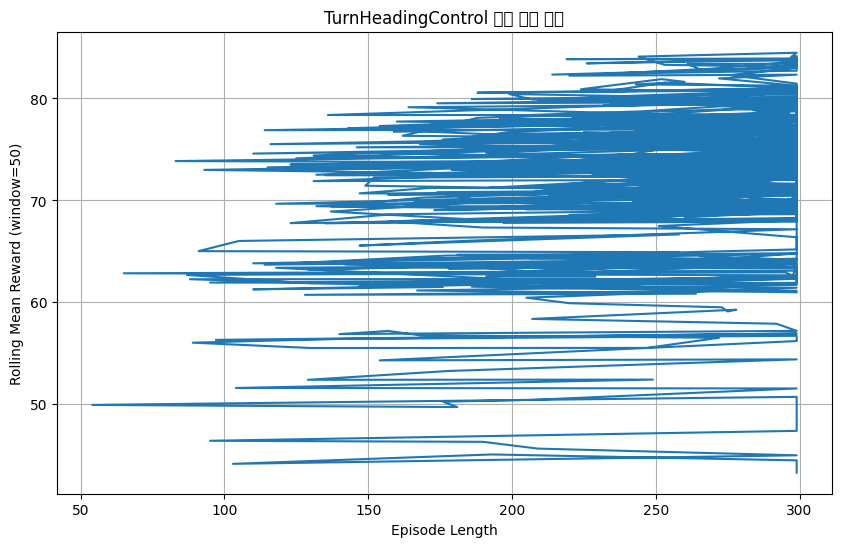

In [ ]:
# 로그 파일에서 episode reward 불러와 시각화
import pandas as pd

# Monitor 로그 CSV 파일 경로
monitor_file = os.path.join(log_dir, os.listdir(log_dir)[0])
data = pd.read_csv(monitor_file, comment='#')

# 누적 에피소드별 평균 보상 계산
data['rolling_reward'] = data['r'].rolling(window=50).mean()

plt.figure(figsize=(10, 6))
plt.plot(data['l'], data['rolling_reward'])
plt.xlabel("Episode Length")
plt.ylabel("Rolling Mean Reward (window=50)")
plt.title("TurnHeadingControl 학습 보상 곡선")
plt.grid(True)
plt.show()


In [2]:
from stable_baselines3.common.evaluation import evaluate_policy

# 저장된 최적 모델 로드
best_model = PPO.load("./best_model/best_model.zip")

# 평가 수행
mean_reward, std_reward = evaluate_policy(
    best_model,
    eval_env,
    n_eval_episodes=20,
    return_episode_rewards=False
)

print(f"평가 에피소드 수: 20")
print(f"평균 보상: {mean_reward:.2f} ± {std_reward:.2f}")


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


NameError: name 'PPO' is not defined